In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import GPT2Model, GPT2Tokenizer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2Model.from_pretrained("gpt2",
                                   output_hidden_states=True)
model.eval()

print("Ready!")

c:\Users\devuser3\AppData\Roaming\uv\python\cpython-3.14.3-windows-x86_64-none\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 6166.62it/s]

Ready!


In [2]:

word_categories = {
    "Royalty":  ["king", "queen", "prince", "princess", "throne", "crown"],
    "Animals":  ["dog", "cat", "horse", "elephant", "tiger", "lion"],
    "Food":     ["pizza", "burger", "pasta", "rice", "bread", "soup"],
    "Emotions": ["happy", "sad", "angry", "scared", "excited", "calm"],
}

colors_map = {
    "Royalty":  "gold",
    "Animals":  "steelblue", 
    "Food":     "coral",
    "Emotions": "green",
}


all_words  = []
all_labels = []
all_embs   = []

for category, words in word_categories.items():
    for word in words:
        inputs = tokenizer(word, return_tensors="pt")
        with torch.no_grad():
            outputs = model(**inputs)
        
        
        emb = outputs.hidden_states[-1][0].mean(dim=0).numpy()
        all_words.append(word)
        all_labels.append(category)
        all_embs.append(emb)

X = np.array(all_embs)
print(f"Total words: {len(all_words)}")
print(f"Embedding shape: {X.shape}")

Total words: 24
Embedding shape: (24, 768)


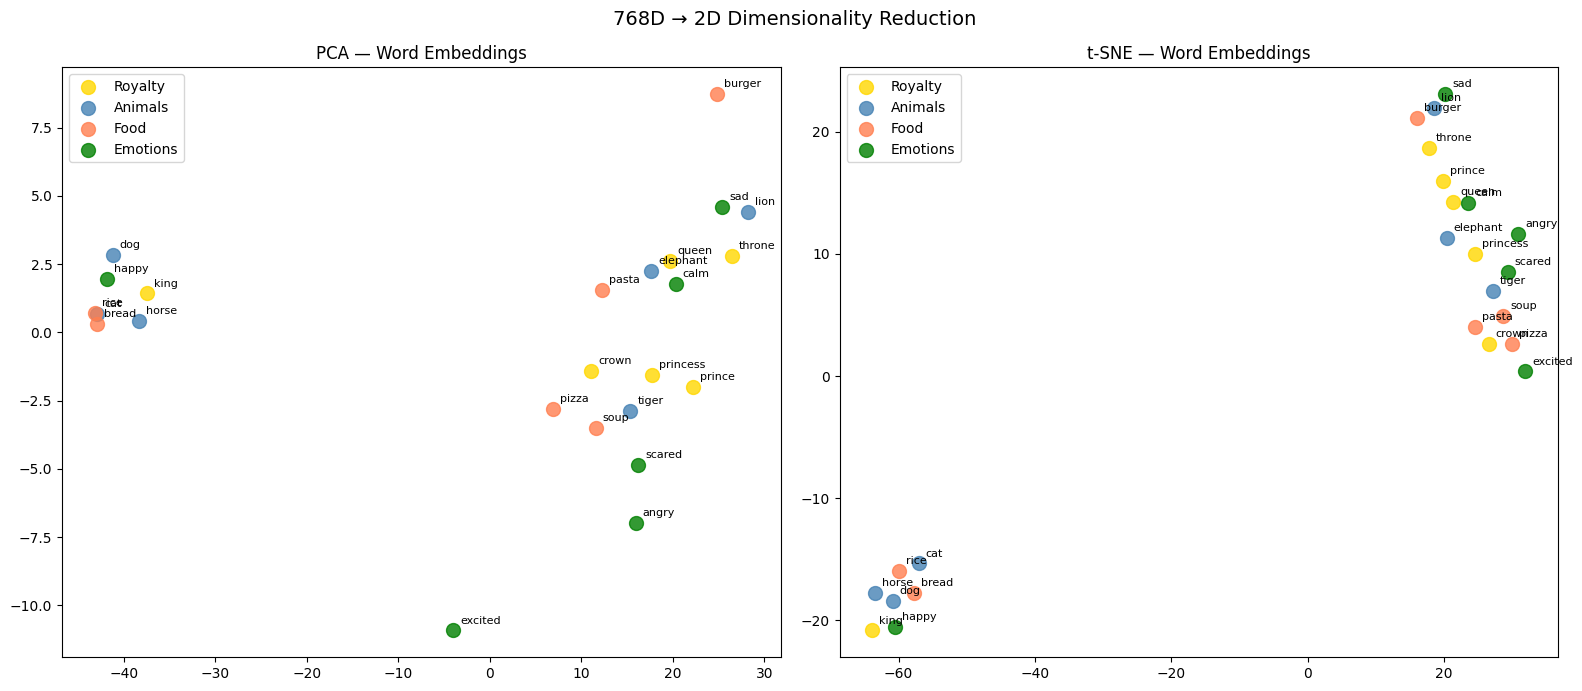

In [3]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)


tsne = TSNE(n_components=2, random_state=42, perplexity=5)
X_tsne = tsne.fit_transform(X)


fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, X_reduced, title in zip(
    axes, 
    [X_pca, X_tsne], 
    ["PCA", "t-SNE"]
):
    for category, color in colors_map.items():
        mask = [l == category for l in all_labels]
        ax.scatter(
            X_reduced[mask, 0],
            X_reduced[mask, 1],
            c=color, label=category, s=100, alpha=0.8
        )
        
        for i, (word, label) in enumerate(zip(all_words, all_labels)):
            if label == category:
                ax.annotate(word, 
                           (X_reduced[i, 0], X_reduced[i, 1]),
                           textcoords="offset points",
                           xytext=(5, 5), fontsize=8)
    
    ax.set_title(f"{title} — Word Embeddings")
    ax.legend()

plt.suptitle("768D → 2D Dimensionality Reduction", fontsize=14)
plt.tight_layout()
plt.show()

* You can reduce **768-dimensional embeddings to 2D**.
* Principal Component Analysis (**PCA**) → linear reduction, fast.
* t-SNE → non-linear, shows better clustering.
* Words from the **same category form clusters**.
* Visual evidence confirms that GPT-2 captures **semantic meaning**.
